Accuracy: 0.8990
Modelo y scaler guardados correctamente
Antes de SMOTE:
Depression
False    71950
True      8050
Name: count, dtype: int64

Después de SMOTE:
Depression
False    71950
True     71950
Name: count, dtype: int64

Accuracy: 0.6963


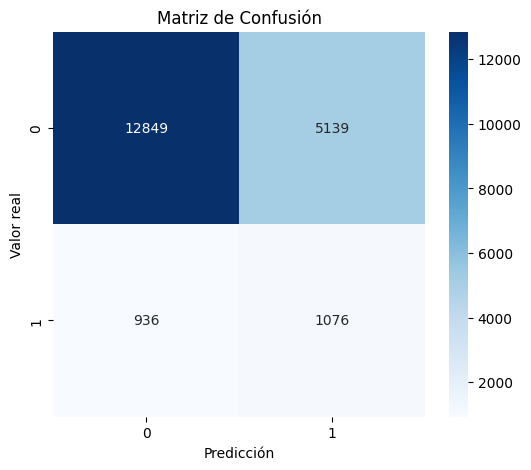


Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.93      0.71      0.81     17988
        True       0.17      0.53      0.26      2012

    accuracy                           0.70     20000
   macro avg       0.55      0.62      0.54     20000
weighted avg       0.86      0.70      0.75     20000



In [2]:
# Importar librerías
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


df = pd.read_csv("/content/student_lifestyle_100k (1).csv")


df["Department"] = df["Department"].astype(str).str.strip().str.lower()

df.loc[df["Department"] == "engineering", "Department"] = 0
df.loc[df["Department"] == "science", "Department"] = 1
df.loc[df["Department"] == "arts", "Department"] = 2
df.loc[df["Department"] == "business", "Department"] = 3
df.loc[df["Department"] == "medical", "Department"] = 4

df["Department"] = df["Department"].astype(int)

df.drop(columns=["Student_ID"], inplace=True)

df["Gender"] = df["Gender"].astype(str).str.strip().str.lower()

df.loc[df["Gender"] == "male", "Gender"] = 0
df.loc[df["Gender"] == "female", "Gender"] = 1

df["Gender"] = df["Gender"].astype(int)


y = df["Depression"]
X = df.drop(columns=["Depression"])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)



model.fit(X_train, y_train)



score = model.score(X_test, y_test)

print(f'Accuracy: {score:.4f}')



joblib.dump(model, "modelo_smote_mlp.pkl")
joblib.dump(scaler, "scaler_smote_mlp.pkl")

print("Modelo y scaler guardados correctamente")

print("Antes de SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDespués de SMOTE:")
print(pd.Series(y_train_bal).value_counts())


model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

# Entrenar
model.fit(X_train_bal, y_train_bal)


score = model.score(X_test, y_test)

print(f"\nAccuracy: {score:.4f}")

# Predicciones
y_pred = model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()


print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))




Después de SMOTE:
Depression
False    71943
True     71943
Name: count, dtype: int64

Accuracy: 0.6880


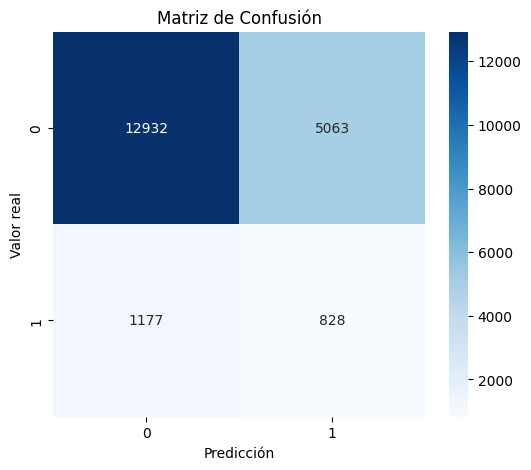


Reporte de clasificación:
              precision    recall  f1-score   support

       False       0.92      0.72      0.81     17995
        True       0.14      0.41      0.21      2005

    accuracy                           0.69     20000
   macro avg       0.53      0.57      0.51     20000
weighted avg       0.84      0.69      0.75     20000

Modelo y scaler guardados correctamente


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import pandas as pd
import joblib


df = pd.read_csv("/content/student_lifestyle_100k (1).csv")
df["Department"] = df["Department"].astype(str)

df["Department"] = df["Department"].str.strip().str.lower()

df.loc[df["Department"] == "engineering", "Department"] = 0
df.loc[df["Department"] == "science", "Department"] = 1
df.loc[df["Department"] == "arts", "Department"] = 2
df.loc[df["Department"] == "business", "Department"] = 3
df.loc[df["Department"] == "medical", "Department"] = 4

df["Department"] = df["Department"].astype(int)

df.drop(columns=["Student_ID"], inplace=True)

df["Gender"] = df["Gender"].astype(str)

df["Gender"] = df["Gender"].str.strip().str.lower()

df.loc[df["Gender"] == "male", "Gender"] = 0
df.loc[df["Gender"] == "female", "Gender"] = 1

df["Gender"] = df["Gender"].astype(int)


X = df.drop("Depression", axis=1)
y = df["Depression"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nDespués de SMOTE:")
print(pd.Series(y_train_bal).value_counts())

model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='minkowski',
    p=2
)



model.fit(X_train_bal, y_train_bal)


score = model.score(X_test, y_test)

print(f"\nAccuracy: {score:.4f}")

# Predicciones
y_pred = model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión")
plt.show()


print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))



joblib.dump(model, 'modelo_smote_knn.pkl')
joblib.dump(scaler, 'scaler_smote_knn.pkl')

print("Modelo y scaler guardados correctamente")